# Ch6: Linear Model Selection and Regularization

### **Q9.**
In this exercise, we will predict the number of applications received using the other variables in the `College` data set.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()

%matplotlib inline

In [2]:
import sklearn.linear_model as skl
import sklearn.model_selection as skm
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from sklearn.preprocessing import StandardScaler
from statsmodels.api import OLS

In [3]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

In [4]:
college = load_data('College')
print(f"Shape: {college.shape}")
college.head()

Shape: (777, 18)


,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [5]:
college.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Private      777 non-null    category
 1   Apps         777 non-null    int64   
 2   Accept       777 non-null    int64   
 3   Enroll       777 non-null    int64   
 4   Top10perc    777 non-null    int64   
 5   Top25perc    777 non-null    int64   
 6   F.Undergrad  777 non-null    int64   
 7   P.Undergrad  777 non-null    int64   
 8   Outstate     777 non-null    int64   
 9   Room.Board   777 non-null    int64   
 10  Books        777 non-null    int64   
 11  Personal     777 non-null    int64   
 12  PhD          777 non-null    int64   
 13  Terminal     777 non-null    int64   
 14  S.F.Ratio    777 non-null    float64 
 15  perc.alumni  777 non-null    int64   
 16  Expend       777 non-null    int64   
 17  Grad.Rate    777 non-null    int64   
dtypes: category(1), float64(1), in

In [6]:
college.describe(include='all')

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,565,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,NaN,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,NaN,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,NaN,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,NaN,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,NaN,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000


---
## (a) Split the data into a training set and a test set

In [7]:
design = MS(college.columns.drop('Apps'))

X = design.fit_transform(college)
y = college['Apps']

X_train, X_test, y_train, y_test = skm.train_test_split(
    X, y, test_size=0.3, random_state=1
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size:     {X_test.shape[0]}")

Training set size: 543
Test set size:     234


---
## (b) OLS — Least squares on the training set

In [8]:
ols_results = OLS(y_train, X_train).fit()
ols_pred = ols_results.predict(X_test)
ols_MSE = np.mean((ols_pred - y_test) ** 2)
ols_MSE

642753.8976532122

The OLS test MSE is approximately **642,754**.

---
## (c) Ridge regression — λ chosen by cross-validation

We drop the intercept column since `RidgeCV` / `ElasticNetCV` add an intercept by default. We use a Pipeline with `StandardScaler` to ensure features are standardized before penalization.

We use a wide log-scale lambda range to ensure the optimum is captured.

In [11]:
# Drop intercept for penalized methods (they add their own)
X_train_no_int = X_train.drop('intercept', axis=1)
X_test_no_int = X_test.drop('intercept', axis=1)

In [12]:
K = 5
lambdas = 10 ** np.linspace(-2, 6, 200)  # wide log-scale range

inner_kfold = skm.KFold(
    n_splits=K, shuffle=True, random_state=2
)

scaler = StandardScaler()

ridgeCV = skl.ElasticNetCV(
    alphas=lambdas,
    l1_ratio=0,       # l1_ratio=0 => ridge
    cv=inner_kfold
)

ridge_pipe = Pipeline([
    ('scaler', scaler),
    ('ridge', ridgeCV)
])

ridge_pipe.fit(X_train_no_int, y_train)

C:\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
C:\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.450e+09, tolerance: 6.901e+05
  model = cd_fast.enet_coordinate_descent_gram(
C:\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
C:\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarn

,steps,"[('scaler', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,l1_ratio,0
,eps,0.001
,n_alphas,'deprecated'
,alphas,array([1.0000...00000000e+06])


In [13]:
tuned_ridge = ridge_pipe.named_steps['ridge']
print(f"Best lambda: {tuned_ridge.alpha_:.4f}")

Best lambda: 0.0100


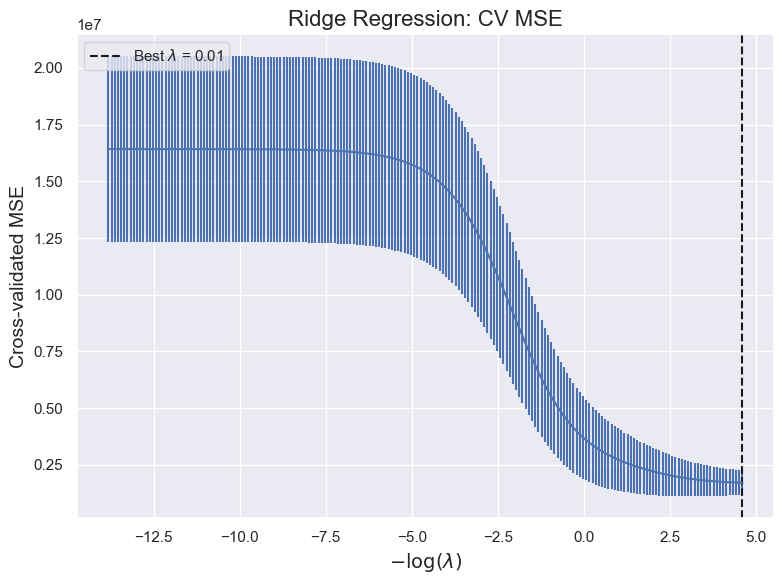

In [14]:
# CV error plot
ridge_fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(
    -np.log(tuned_ridge.alphas_),
    tuned_ridge.mse_path_.mean(1),
    yerr=tuned_ridge.mse_path_.std(1) / np.sqrt(K)
)
ax.axvline(-np.log(tuned_ridge.alpha_), c='k', ls='--', label=f'Best $\\lambda$ = {tuned_ridge.alpha_:.2f}')
ax.set_xlabel('$-\\log(\\lambda)$', fontsize=14)
ax.set_ylabel('Cross-validated MSE', fontsize=14)
ax.set_title('Ridge Regression: CV MSE', fontsize=16)
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
ridge_pred = ridge_pipe.predict(X_test_no_int)
ridge_MSE = np.mean((ridge_pred - y_test) ** 2)
ridge_MSE

657856.0840323347

---
## (d) Lasso — λ chosen by cross-validation

We use `LassoCV` (equivalent to `ElasticNetCV` with `l1_ratio=1`, but more direct and readable for a pure Lasso).

In [16]:
lassoCV = skl.LassoCV(
    n_alphas=100,
    cv=inner_kfold,
    max_iter=10000
)

lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', lassoCV)
])

lasso_pipe.fit(X_train_no_int, y_train)

C:\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


,steps,"[('scaler', ...), ('lasso', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,eps,0.001
,n_alphas,100
,alphas,'warn'
,fit_intercept,True


In [ ]:
tuned_lasso = lasso_pipe.named_steps['lasso']
print(f"Best lambda: {tuned_lasso.alpha_:.4f}")

In [ ]:
# CV error plot
lasso_fig, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(
    -np.log(tuned_lasso.alphas_),
    tuned_lasso.mse_path_.mean(1),
    yerr=tuned_lasso.mse_path_.std(1) / np.sqrt(K)
)
ax.axvline(-np.log(tuned_lasso.alpha_), c='k', ls='--', label=f'Best $\\lambda$ = {tuned_lasso.alpha_:.2f}')
ax.set_xlabel('$-\\log(\\lambda)$', fontsize=14)
ax.set_ylabel('Cross-validated MSE', fontsize=14)
ax.set_title('Lasso: CV MSE', fontsize=16)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
lasso_pred = lasso_pipe.predict(X_test_no_int)
lasso_MSE = np.mean((lasso_pred - y_test) ** 2)
lasso_MSE

In [ ]:
# Non-zero coefficients (excluding intercept, which is always non-zero and unpenalized)
n_nonzero = np.sum(tuned_lasso.coef_ != 0)
print(f"Non-zero coefficient estimates: {n_nonzero} out of {len(tuned_lasso.coef_)}")
print(f"(The intercept is always non-zero and unpenalized, so it is not counted above.)")
print()
print("Coefficient values:")
coef_series = pd.Series(tuned_lasso.coef_, index=X_train_no_int.columns)
coef_series

---
## (e) PCR — M chosen by cross-validation

In [ ]:
scaler = StandardScaler()
pca = PCA()
linreg = LinearRegression()

pcr_pipe = Pipeline([
    ('scaler', scaler),
    ('pca', pca),
    ('linreg', linreg)
])

p = X_train_no_int.shape[1]
param_grid = {'pca__n_components': range(1, p + 1)}

pcr_grid = skm.GridSearchCV(
    pcr_pipe,
    param_grid,
    cv=inner_kfold,
    scoring='neg_mean_squared_error'
)

pcr_grid.fit(X_train_no_int, y_train)
pcr_grid.best_params_

In [ ]:
# CV error plot
pcr_fig, ax = plt.subplots(figsize=(8, 6))
n_comp = list(param_grid['pca__n_components'])
ax.errorbar(
    n_comp,
    -pcr_grid.cv_results_['mean_test_score'],
    yerr=pcr_grid.cv_results_['std_test_score'] / np.sqrt(K)
)
best_m_pcr = pcr_grid.best_params_['pca__n_components']
ax.axvline(best_m_pcr, c='k', ls='--', label=f'Best M = {best_m_pcr}')
ax.set_xlabel('# Principal Components', fontsize=14)
ax.set_ylabel('Cross-validated MSE', fontsize=14)
ax.set_title('PCR: CV MSE', fontsize=16)
ax.set_xticks(n_comp[::2])
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Fit final PCR model with best M and evaluate on test set
pcr_pipe.named_steps['pca'].n_components = best_m_pcr
pcr_pipe.fit(X_train_no_int, y_train)
pcr_pred = pcr_pipe.predict(X_test_no_int)
pcr_MSE = np.mean((pcr_pred - y_test) ** 2)

print(f"Best M: {best_m_pcr}")
print(f"PCR Test MSE: {pcr_MSE:.2f}")

Cross-validation selects $M = 17$ (all components), so PCR here is equivalent to OLS — fitting all $p$ principal components recovers the full least squares solution. This is not surprising when none of the components are clearly irrelevant.

---
## (f) PLS — M chosen by cross-validation

In [ ]:
pls = PLSRegression(scale=True)

pls_param_grid = {'n_components': range(1, p + 1)}

pls_grid = skm.GridSearchCV(
    pls,
    pls_param_grid,
    cv=inner_kfold,
    scoring='neg_mean_squared_error'
)

pls_grid.fit(X_train_no_int, y_train)
pls_grid.best_params_

In [ ]:
# CV error plot
pls_fig, ax = plt.subplots(figsize=(8, 6))
n_comp_pls = list(pls_param_grid['n_components'])
ax.errorbar(
    n_comp_pls,
    -pls_grid.cv_results_['mean_test_score'],
    yerr=pls_grid.cv_results_['std_test_score'] / np.sqrt(K)
)
best_m_pls = pls_grid.best_params_['n_components']
ax.axvline(best_m_pls, c='k', ls='--', label=f'Best M = {best_m_pls}')
ax.set_xlabel('# PLS Components', fontsize=14)
ax.set_ylabel('Cross-validated MSE', fontsize=14)
ax.set_title('PLS: CV MSE', fontsize=16)
ax.set_xticks(n_comp_pls[::2])
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Fit final PLS model with best M and evaluate on test set
pls_final = PLSRegression(n_components=best_m_pls, scale=True)
pls_final.fit(X_train_no_int, y_train)
pls_pred = pls_final.predict(X_test_no_int).ravel()
pls_MSE = np.mean((pls_pred - y_test) ** 2)

print(f"Best M: {best_m_pls}")
print(f"PLS Test MSE: {pls_MSE:.2f}")

---
## (g) Summary and comparison

In [ ]:
approaches = ['OLS', 'Ridge', 'Lasso', 'PCR', 'PLS']
mse_values = [ols_MSE, ridge_MSE, lasso_MSE, pcr_MSE, pls_MSE]
rmse_values = np.sqrt(mse_values)

results_df = pd.DataFrame({
    'Method': approaches,
    'Test MSE': mse_values,
    'Test RMSE': rmse_values
}).sort_values('Test MSE').reset_index(drop=True)

results_df

In [ ]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
bars = ax.bar(results_df['Method'], results_df['Test RMSE'], color=colors)
ax.set_ylabel('Test RMSE', fontsize=14)
ax.set_title('Comparison of Test RMSE Across the 5 Approaches', fontsize=16)

# Annotate bars with RMSE values
for bar, val in zip(bars, results_df['Test RMSE']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# RMSE as a percentage of mean Apps — gives practical context
best_rmse = results_df['Test RMSE'].min()
mean_apps = college['Apps'].mean()

print(f"Best RMSE:          {best_rmse:.1f}")
print(f"Mean applications:  {mean_apps:.1f}")
print(f"RMSE / Mean Apps:   {best_rmse / mean_apps:.1%}")

### Comment

Comparing the RMSE across all five approaches, there is relatively little difference among them. PLS edges out slightly in first place, with OLS and PCR (M=17) tied for second — which makes sense since PCR with all components is equivalent to OLS. Ridge comes next, and Lasso last, though the differences are modest.

The best RMSE is roughly 27% of the mean number of applications, meaning our predictions deviate from the actual count by about 800 applications on average. Whether this is acceptable depends on the context and intended use of the model.

Key observations:
- **Ridge** and **Lasso** do not dramatically outperform OLS here, suggesting that the bias–variance tradeoff from shrinkage provides only modest gains for this dataset.
- **Lasso** has the advantage of sparsity (some coefficients are zeroed out), which can aid interpretability, even if its test error is slightly higher.
- **PCR** selects all 17 components, effectively recovering OLS — no dimension reduction benefit on this data.
- **PLS** achieves a marginally lower error with fewer components than PCR, as expected since PLS finds directions that account for variation in both the predictors and the response.

Overall, there is not much difference among the five approaches for this dataset.